# Exploratory Data Analysis (EDA): Basel Pillars
This notebook explores patterns for PD, LGD, and EAD.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style='whitegrid')

df_final = pd.DataFrame({
    'person_income': np.random.normal(50000, 15000, 1000).clip(20000, 1000000),
    'loan_status': np.random.choice([0, 1], 1000, p=[0.8, 0.2]),
    'cb_person_cred_hist_length': np.random.randint(1, 30, 1000)
})
df_final['mock_recovery_rate'] = np.random.uniform(0.1, 0.9, size=1000)
df_final['mock_exposure'] = df_final['person_income'] * np.random.uniform(0.1, 0.4, size=1000)


### 1. PD Analysis

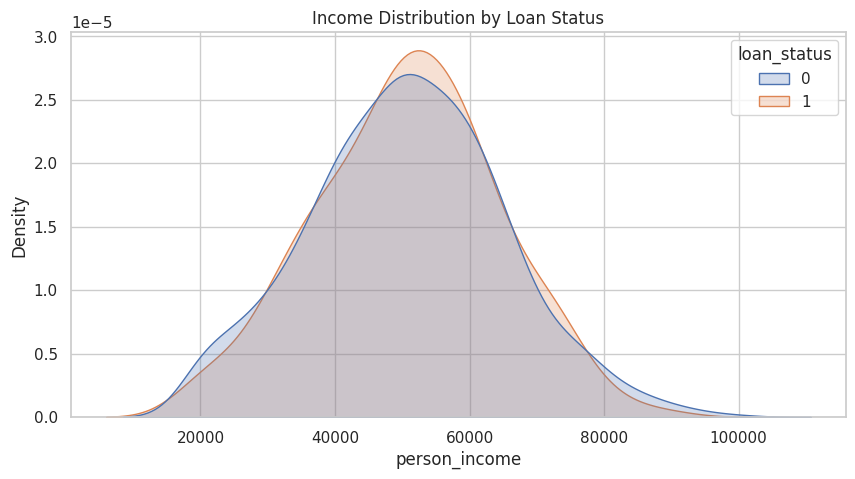

In [2]:
plt.figure(figsize=(10, 5))
sns.kdeplot(data=df_final, x='person_income', hue='loan_status', fill=True, common_norm=False)
plt.title('Income Distribution by Loan Status')
plt.show()

### 2. LGD & EAD Analysis

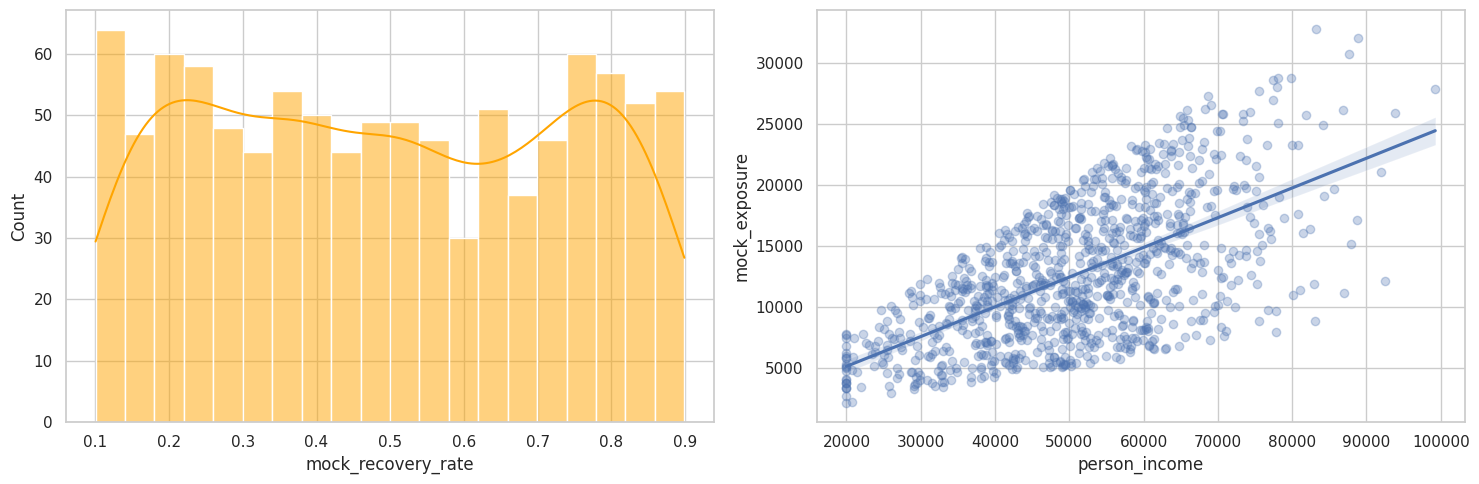

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))
sns.histplot(df_final['mock_recovery_rate'], bins=20, kde=True, ax=axes[0], color='orange')
sns.regplot(data=df_final, x='person_income', y='mock_exposure', ax=axes[1], scatter_kws={'alpha':0.3})
plt.tight_layout()
plt.show()

### 3. Correlation Matrix

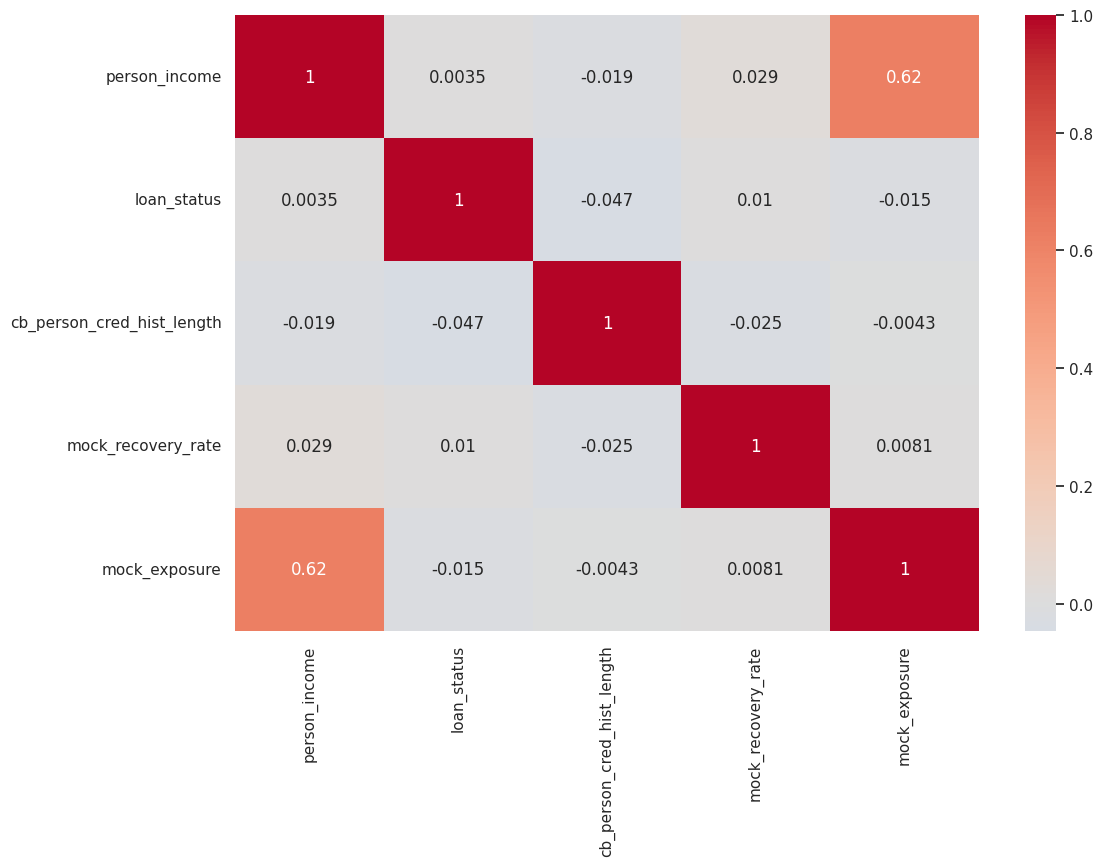

In [4]:
plt.figure(figsize=(12, 8))
sns.heatmap(df_final.corr(), annot=True, cmap='coolwarm', center=0)
plt.show()